# Correlation Coefficient between Coherence Measurements and Human Annotation

In [4]:
# @title Utils and Load Human Data

from google.colab import drive
drive.mount('/content/drive')

dataset_dir = "/content/drive/MyDrive/LLM Auction-release/dataset/"


import pandas as pd
import numpy as np

def calculate_statistics(csv_file):
    """
    Calculate the mean and median for each column in a CSV file.

    Args:
        csv_file (str): Path to the CSV file

    Returns:
        dict: Dictionary containing mean and median for each column
    """
    # Read the CSV file
    try:
        df = pd.read_csv(csv_file)
        print(f"Successfully read CSV file with {df.shape[0]} rows and {df.shape[1]} columns")
        print(f"Column names: {df.columns.tolist()}")
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return None

    # Dictionary to store results
    results = {'mean':{}}

    # Calculate statistics for each column
    for column in df.columns:
        try:
            # pd.to_numeric will attempt to convert strings to numbers
            numeric_series = pd.to_numeric(df[column], errors='coerce')

            # Check if we have any non-NaN values after conversion
            if numeric_series.notna().any():
                mean_value = numeric_series.mean()

                results['mean'][column] = mean_value

        except Exception as e:
            print(f"Error processing column '{column}': {e}")

    return results

file_path = dataset_dir + 'human_annotation.csv'
human_stats = calculate_statistics(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully read CSV file with 36 rows and 311 columns
Column names: ['Unnamed: 0', 'T01A01.0', 'T01A01.1', 'T01A01.2', 'T01A01.3', 'T01A01.4', 'T01A01.5', 'T01A01.6', 'T01A01.7', 'T01A01.8', 'T01A01.9', 'T01A02.0', 'T01A02.1', 'T01A02.2', 'T01A02.3', 'T01A02.4', 'T01A02.5', 'T01A02.6', 'T01A02.7', 'T01A02.8', 'T01A02.9', 'T01A03.0', 'T01A03.1', 'T01A03.2', 'T01A03.3', 'T01A03.4', 'T01A03.5', 'T01A03.6', 'T01A03.7', 'T01A03.8', 'T01A03.9', 'T01A04.0', 'T01A04.1', 'T01A04.2', 'T01A04.3', 'T01A04.4', 'T01A04.5', 'T01A04.6', 'T01A04.7', 'T01A04.8', 'T01A04.9', 'T01A05.0', 'T01A05.1', 'T01A05.2', 'T01A05.3', 'T01A05.4', 'T01A05.5', 'T01A05.6', 'T01A05.7', 'T01A05.8', 'T01A05.9', 'T02A01.0', 'T02A01.1', 'T02A01.2', 'T02A01.3', 'T02A01.4', 'T02A01.5', 'T02A01.6', 'T02A01.7', 'T02A01.8', 'T02A01.9', 'T02A02.0', 'T02A02.1', 'T02A02.2', 'T02A02.3', 'T02A02.4', 'T02A0

In [5]:
# @title Load LLM Coherence Measurements data

import csv

scorer_results = {}

with open(dataset_dir + "scorer_results.csv", "r", newline="") as f:
    reader = csv.reader(f)
    header = next(reader)[1:]  # Skip the empty top-left cell

    for row in reader:
        outer_key = row[0]
        values = row[1:]
        subdict = {}
        for key, value in zip(header, values):
            if value == " ":
                subdict[key] = 0
            else:
                subdict[key] = float(value) if value else 0
        scorer_results[outer_key] = subdict

print(scorer_results)
print(human_stats)


{'lmexaminer-gpt4omini': {'T01A01.0': 5.0, 'T01A01.1': 3.0, 'T01A01.2': 1.0, 'T01A01.3': 2.0, 'T01A01.4': 1.0, 'T01A01.5': 3.0, 'T01A01.6': 5.0, 'T01A01.7': 2.0, 'T01A01.8': 1.0, 'T01A01.9': 4.0, 'T01A02.0': 5.0, 'T01A02.1': 3.0, 'T01A02.2': 1.0, 'T01A02.3': 2.0, 'T01A02.4': 1.0, 'T01A02.5': 3.0, 'T01A02.6': 5.0, 'T01A02.7': 2.0, 'T01A02.8': 1.0, 'T01A02.9': 5.0, 'T01A03.0': 5.0, 'T01A03.1': 3.0, 'T01A03.2': 1.0, 'T01A03.3': 2.0, 'T01A03.4': 1.0, 'T01A03.5': 3.0, 'T01A03.6': 5.0, 'T01A03.7': 2.0, 'T01A03.8': 1.0, 'T01A03.9': 5.0, 'T01A04.0': 5.0, 'T01A04.1': 2.0, 'T01A04.2': 1.0, 'T01A04.3': 1.0, 'T01A04.4': 1.0, 'T01A04.5': 3.0, 'T01A04.6': 5.0, 'T01A04.7': 1.0, 'T01A04.8': 1.0, 'T01A04.9': 5.0, 'T01A05.0': 5.0, 'T01A05.1': 3.0, 'T01A05.2': 1.0, 'T01A05.3': 2.0, 'T01A05.4': 1.0, 'T01A05.5': 3.0, 'T01A05.6': 5.0, 'T01A05.7': 2.0, 'T01A05.8': 1.0, 'T01A05.9': 5.0, 'T02A01.0': 2.0, 'T02A01.1': 3.0, 'T02A01.2': 1.0, 'T02A01.3': 5.0, 'T02A01.4': 2.0, 'T02A01.5': 3.0, 'T02A01.6': 1.0, 'T02A

In [6]:
# @title Compute Correlation Coefficient

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr


def dicts_to_dataframe(d):
    return pd.DataFrame(d).T  # rows: outer keys, columns: inner keys

all_lm_mean = {}
for key, value in scorer_results.items():
    if not key in ["lmexaminer-gpt5","lmexaminer-deepseek-r1"]:
        continue
    for inner_key in value:
        if inner_key not in all_lm_mean:
            all_lm_mean[inner_key] = []
        all_lm_mean[inner_key].append(value[inner_key])

for key, value in all_lm_mean.items():
    all_lm_mean[key] = np.mean(value)

scorer_results['lmexaminer-mean-gpt5-r1'] = all_lm_mean


all_lm_mean = {}
for key, value in scorer_results.items():
    if not key in ["lmexaminer-gpt5","lmexaminer-gpt4o","lmexaminer-gpt4omini","lmexaminer-deepseek-r1","lmexaminer-deepseek-v3"]:
        continue
    for inner_key in value:
        if inner_key not in all_lm_mean:
            all_lm_mean[inner_key] = []
        all_lm_mean[inner_key].append(value[inner_key])

for key, value in all_lm_mean.items():
    all_lm_mean[key] = np.mean(value)

scorer_results['lmexaminer-mean-all'] = all_lm_mean

# Convert to DataFrames
df1 = dicts_to_dataframe(human_stats)
df2 = dicts_to_dataframe(scorer_results)

# Compute correlation matrix
correlation_matrix = df1.apply(lambda row1: df2.apply(lambda row2: spearmanr(row1, row2).correlation, axis=1), axis=1)

print(correlation_matrix)


      lmexaminer-gpt4omini  lmexaminer-gpt4o  lmexaminer-deepseek-r1  \
mean              0.585563          0.638005                0.665045   

      lmexaminer-gpt5  embedding-qwen3-8b  embedding-qwen3-4b  \
mean         0.663736            0.311564            0.283756   

      embedding-qwen3-0.6b  lmexaminer-deepseek-v3  lmexaminer-qwen3-8b  \
mean              0.270128                0.663642             0.553236   

      lmexaminer-qwen3-32b  lmexaminer-mean-gpt5-r1  lmexaminer-mean-all  
mean              0.580361                 0.696178             0.712711  


# Compute Survey Equivalence

In [7]:
# @title Compute committee correlations for K=1,2,3,4.
import itertools
import random
from typing import Tuple
import math

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from google.colab import drive
drive.mount('/content/drive')

dataset_dir = "/content/drive/MyDrive/LLM Auction-release/dataset/"

raw = pd.read_csv(dataset_dir+"human_annotation.csv", dtype=str, keep_default_na=True, na_values=["", "NA", "NaN"])
df_numeric = raw.apply(pd.to_numeric, errors="coerce")
keep_mask = df_numeric.isna().mean(axis=1) <= 0.5
clean = df_numeric.loc[keep_mask].copy()

# Keep tasks with at least one non-NaN
valid_task_mask = clean.notna().any(axis=0)
clean = clean.loc[:, valid_task_mask]

data = clean.to_numpy(dtype=float)
P, T = data.shape

counts = (~np.isnan(data)).astype(np.int32)
sum_values = np.nan_to_num(data, nan=0.0)

count_all = counts.sum(axis=0)
sum_all = sum_values.sum(axis=0)

def safe_spearman(x: np.ndarray, y: np.ndarray) -> Tuple[float, float, int]:
    mask = ~np.isnan(x) & ~np.isnan(y)
    n = int(mask.sum())
    if n < 2:
        return (np.nan, np.nan, n)
    r, p = spearmanr(x[mask], y[mask])
    return (float(r), float(p), n)

def eval_committees(K: int, num_samples: int = None) -> pd.DataFrame:
    records = []
    if num_samples and num_samples < math.comb(P, K):
        # Sample combinations
        all_indices = list(range(P))
        for _ in range(num_samples):
            combo = tuple(random.sample(all_indices, K))
            sum_S = sum_values[list(combo), :].sum(axis=0)
            count_S = counts[list(combo), :].sum(axis=0)

            with np.errstate(invalid='ignore', divide='ignore'):
                comm_mean = sum_S / count_S
                comm_mean[count_S == 0] = np.nan

            lo_count = count_all - count_S
            lo_sum = sum_all - sum_S
            with np.errstate(invalid='ignore', divide='ignore'):
                lo_mean = lo_sum / lo_count
                lo_mean[lo_count == 0] = np.nan

            r, p, n = safe_spearman(comm_mean, lo_mean)
            orig_ids = tuple(int(clean.index[i]) for i in combo)
            records.append({"committee": orig_ids, "spearman_r": r, "p_value": p, "overlapping_tasks": n})
    else:
        # Enumerate all combinations
        for combo in itertools.combinations(range(P), K):
            sum_S = sum_values[list(combo), :].sum(axis=0)
            count_S = counts[list(combo), :].sum(axis=0)

            with np.errstate(invalid='ignore', divide='ignore'):
                comm_mean = sum_S / count_S
                comm_mean[count_S == 0] = np.nan

            lo_count = count_all - count_S
            lo_sum = sum_all - sum_S
            with np.errstate(invalid='ignore', divide='ignore'):
                lo_mean = lo_sum / lo_count
                lo_mean[lo_count == 0] = np.nan

            r, p, n = safe_spearman(comm_mean, lo_mean)
            orig_ids = tuple(int(clean.index[i]) for i in combo)
            records.append({"committee": orig_ids, "spearman_r": r, "p_value": p, "overlapping_tasks": n})
    return pd.DataFrame.from_records(records)

k1_leave = eval_committees(1)
k2_leave = eval_committees(2)
k3_leave = eval_committees(3)
k4_leave = eval_committees(4, num_samples=10000) # Sample 10000 for K=4

def summarize(df: pd.DataFrame, k_label: str):
    valid = df["spearman_r"].dropna()
    print(f"{k_label}: committees={len(df)}")
    if not valid.empty:
        print(f"Spearman r: mean={valid.mean():.4f}, std={valid.std(ddof=1):.4f}, min={valid.min():.4f}, max={valid.max():.4f}")

print("=== Leave-out committee correlations (committee mean vs. mean of everyone ELSE) ===")
summarize(k1_leave, "K=1")
summarize(k2_leave, "K=2")
summarize(k3_leave, "K=3")
summarize(k4_leave, "K=4 (sampled)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Leave-out committee correlations (committee mean vs. mean of everyone ELSE) ===
K=1: committees=36
Spearman r: mean=0.5565, std=0.2127, min=-0.4719, max=0.7647
K=2: committees=630
Spearman r: mean=0.6800, std=0.1215, min=-0.1706, max=0.8345
K=3: committees=7140
Spearman r: mean=0.7419, std=0.0865, min=-0.0176, max=0.8665
K=4 (sampled): committees=10000
Spearman r: mean=0.7806, std=0.0670, min=0.3188, max=0.8810


In [9]:
# Add calculation for K=5,6
k5_leave = eval_committees(5, num_samples=10000) # Sample 10000 for K=5
summarize(k5_leave, "K=5 (sampled)")

k6_leave = eval_committees(6, num_samples=10000) # Sample 10000 for K=6
summarize(k6_leave, "K=6 (sampled)")

K=5 (sampled): committees=10000
Spearman r: mean=0.8065, std=0.0538, min=0.3722, max=0.8904
K=6 (sampled): committees=10000
Spearman r: mean=0.8244, std=0.0444, min=0.4371, max=0.9037


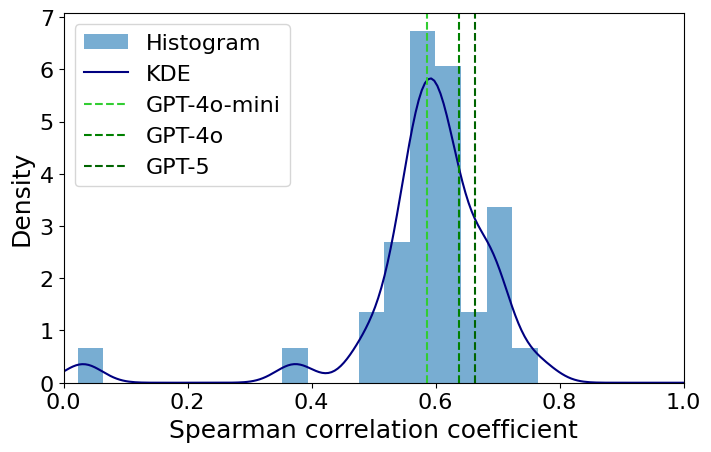

In [25]:
# @title Visualize the distribution of Spearman correlation coefficient for a random person and LLM coherence Measurements

figure_dir = "/content/drive/MyDrive/LLM Auction-release/figures/"
outfile = figure_dir + 'human-correlation-dist.png'

labelsize = 18
ticksize = 16

# Visualize correlations

def visualize_correlations(df: pd.DataFrame, k_label: str, baselines: dict = None):


    valid = df["spearman_r"].dropna()
    n_bins=min(int(np.sqrt(len(valid)))*5,50)
    bw_mult = n_bins / 100.0
    if not valid.empty:
        plt.figure(figsize=(8, 4.8))
        plt.hist(valid, bins = n_bins, density=True, alpha=0.6, label='Histogram')
        kde = gaussian_kde(valid, bw_method=lambda k: k.scotts_factor() * bw_mult)
        xs = np.linspace(0, 1, 200)
        plt.plot(xs, kde(xs), '-', label='KDE', color="navy")
        plt.xlim(0, 1)

        if baselines:
            colors = ['limegreen', 'green', 'darkgreen']
            for i, (name, corr) in enumerate(baselines.items()):
                plt.axvline(x=corr, color=colors[i % len(colors)], linestyle='--', label=name) # Use modulo to cycle through colors

        plt.xlabel("Spearman correlation coefficient", fontsize=labelsize)
        plt.ylabel("Density", fontsize=labelsize)
        plt.xticks(fontsize=ticksize)
        plt.yticks(fontsize=ticksize)
        plt.legend(loc='upper left', fontsize=ticksize)
        # plt.title(f"Distribution of Spearman correlations for {k_label}")
        # plt.show()
        plt.savefig(outfile, dpi=600, bbox_inches='tight', pad_inches=0.05)

baselines = {}
baselines["GPT-4o-mini"] = correlation_matrix["lmexaminer-gpt4omini"]["mean"]
baselines["GPT-4o"] = correlation_matrix["lmexaminer-gpt4o"]["mean"]
baselines["GPT-5"] = correlation_matrix["lmexaminer-gpt5"]["mean"]

visualize_correlations(k1_leave, "a random human", baselines = baselines)

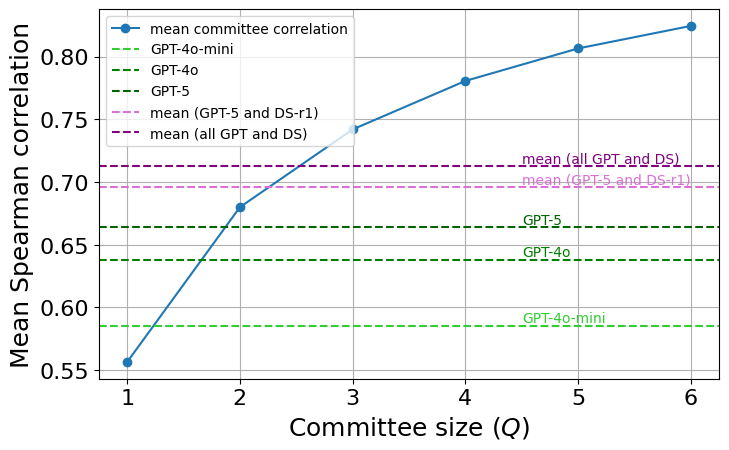

In [26]:
# @title Visualize the mean Spearman correlation coefficient for different K and LLM coherence Measurements

k_values = [1, 2, 3, 4, 5, 6]
mean_correlations = [k1_leave["spearman_r"].mean(), k2_leave["spearman_r"].mean(), k3_leave["spearman_r"].mean(), k4_leave["spearman_r"].mean(), k5_leave["spearman_r"].mean(), k6_leave["spearman_r"].mean()]

baselines = {}
baselines["GPT-4o-mini"] = correlation_matrix["lmexaminer-gpt4omini"]["mean"]
baselines["GPT-4o"] = correlation_matrix["lmexaminer-gpt4o"]["mean"]
baselines["GPT-5"] = correlation_matrix["lmexaminer-gpt5"]["mean"]
baselines["mean (GPT-5 and DS-r1)"] = correlation_matrix["lmexaminer-mean-gpt5-r1"]["mean"]
baselines["mean (all GPT and DS)"] = correlation_matrix["lmexaminer-mean-all"]["mean"]


plt.figure(figsize=(8, 4.8))
plt.plot(k_values, mean_correlations, marker='o', linestyle='-', label='mean committee correlation')

colors = ['limegreen', 'green', 'darkgreen', 'orchid', 'purple']
for i, (name, corr) in enumerate(baselines.items()):
    plt.axhline(y=corr, color=colors[i % len(colors)], linestyle='--', label=name)
    plt.text(x=k_values[-1] - 1.5, y=corr + 0.006, s=name, color=colors[i % len(colors)], va='center')
    # plt.text(k_values[-1] - 1.2, corr + 0.006, name, va='center', color=colors[i % len(colors)])


outfile = figure_dir + 'survey-eq.png'

plt.xlabel(r"Committee size ($Q$)", fontsize=labelsize)
plt.ylabel("Mean Spearman correlation", fontsize=labelsize)
# plt.title("Mean Spearman Correlation vs. Committee Size")
plt.xticks(k_values, fontsize=ticksize)
plt.yticks(fontsize=ticksize)
plt.legend(loc='upper left')
plt.grid(True)
# plt.legend()
# plt.show()
plt.savefig(outfile, dpi=600, bbox_inches='tight', pad_inches=0.05)